# Time Dependent Hamiltonian: B1 Field
#### Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay
## Email: vineeth.thalakottoor@cea.fr


In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)
import numpy as np

import time
%matplotlib ipympl

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QuantumSystem          (QuantumSystem from PyOR_QuantumSystem - for single quantum system)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystems - for multiple quantum systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalC

In [2]:
# Define the spin system
Spin_list = {"A" : "H1"}
QS = QuantumSystem(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am

To see the matrix form use the attribute .matrix


### Set parameters

In [3]:
QS.Configure(
    # Propagation Space
    PropagationSpace="Hilbert",

    # Master Equation
    MasterEquation="Lindblad",

    # Operator basis
    Basis_SpinOperators_Hilbert="Zeeman",

    # Field in TFalse
    B0=9.4,

    # Offset frequencies in Hz
    OFFSET={"A": 10.0},

    # Initial and final spin temperature
    I_spintemp={"A": 300.0},
    F_spintemp={"A": 300.0},

    # Relaxation process
    Rprocess="user Defined Dissipator",
 
    # Evolution parameters
    AcqDT = 0.0001,
    AcqAQ = 1.0,
    OdeMethod = 'DOP853',
    PropagationMethod = "ODE Solver",
    
    #Plotting
    PlotFigureSize = (10,5),
    PlotFontSize = 20
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2514708003.2000003] from {'A': -2514708003.2000003}
Offset    <- OFFSET    : [10.0] from {'A': 10.0}
Ispintemp <- I_spintemp: [300.0] from {'A': 300.0}
Fspintemp <- F_spintemp: [300.0] from {'A': 300.0}
RDxi      <- RD_xi     : [0] from {'A': 0}
RDphase   <- RD_phase  : [0] from {'A': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-400.22821914]
Larmor Frequency in MHz:  [-400.22821914]
Larmor Frequency in MHz:  [-400.22821914]


### Generate Hamiltonians

In [4]:
Hz = QS.Hamiltonian.Zeeman_RotFrame()
Hz.Inverse2PI().Round(3).matrix

Matrix([
[-5.0,   0],
[   0, 5.0]])

In [5]:
# B1 Hamiltonian
B1_Amp = 1.0
def H_mw(t):
    return 2.0 * np.pi * B1_Amp * (QS.Ax * np.cos(2.0 * np.pi * -10.0 *t) + QS.Ay * np.sin(2.0 * np.pi * -10.0 *t))

## Product Operator Basis (PMZ / Shift Z basis)

In [6]:
sort = 'negative to positive'
Index = False
Normal = True
Basis_PMZ, coh_PMZ, dic_PMZ = QS.Basis.ProductOperators_SpinHalf_PMZ(sort,Index,Normal)

In [7]:
Basis_PMZ[0].matrix

Matrix([
[  0, 0],
[1.0, 0]])

In [8]:
print(type(Basis_PMZ))

<class 'list'>


### Product Operator Basis Zeeman

In [9]:
Basis_Zeeman, dic_Zeeman, coh_Zeeman, coh_Zeeman_array = QS.Basis.ProductOperators_Zeeman()

## Initialize density matrix

In [10]:
Thermal_DensMatrix = False

if Thermal_DensMatrix:    
    # High Temperature
    HT_approx = False
    
    # Initial Density Matrix
    rho_in = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Ispintemp,HT_approx)
    
    # Equlibrium Density Matrix
    rhoeq = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Fspintemp,HT_approx)
else:
    rho_in = QS.Az
    rhoeq = QS.Az

In [11]:
QS.DensityMatrix.DensityMatrix_Components(rho_in,Basis_PMZ,dic_PMZ)

Density Matrix = 0.70711 Iz 


In [12]:
QS.DensityMatrix.DensityMatrix_Components(rho_in,Basis_Zeeman, dic_Zeeman)

Density Matrix = 0.5 |1/2,1/2⟩⟨1/2,1/2| + -0.5 |1/2,-1/2⟩⟨1/2,-1/2|


In [13]:
# Initial Density Matrix
rho_in.matrix

Matrix([
[0.5,    0],
[  0, -0.5]])

In [14]:
# Final Density Matrix
rhoeq.matrix

Matrix([
[0.5,    0],
[  0, -0.5]])

## Hard Pulse

In [15]:
flip_angle1 = 0.0   # Flip angle Spin 1

rho = QS.HardPulse.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)

In [16]:
rho.matrix

Matrix([
[0.5,    0],
[  0, -0.5]])

In [17]:
rho.matrix

Matrix([
[0.5,    0],
[  0, -0.5]])

In [18]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_PMZ,dic_PMZ)

Density Matrix = 0.70711 Iz 


In [19]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_Zeeman, dic_Zeeman)

Density Matrix = 0.5 |1/2,1/2⟩⟨1/2,1/2| + -0.5 |1/2,-1/2⟩⟨1/2,-1/2|


## Evolution

In [20]:
QS.Configure(
    uDissipator = [(0.0, QS.Az, QS.Az), (0.0, QS.Ap, QS.Ap), (0.0, QS.Am, QS.Am)],
    uDissipator_only_anticomm = False,  # Select Haberkorn (True) or Lindblad (False)
    ShapeFunc_or_Hamiltonian = "User Defined Hamiltonian"
)

start_time = time.time()
QS.Evolutions.Set_UserDefinedHamiltonian(H_mw)
t, rho_t = QS.Evolutions.Evolution(rho,rhoeq,Hz)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2514708003.2000003] from {'A': -2514708003.2000003}
Offset    <- OFFSET    : [10.0] from {'A': 10.0}
Ispintemp <- I_spintemp: [300.0] from {'A': 300.0}
Fspintemp <- F_spintemp: [300.0] from {'A': 300.0}
RDxi      <- RD_xi     : [0] from {'A': 0}
RDphase   <- RD_phase  : [0] from {'A': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-400.22821914]
Larmor Frequency in MHz:  [-400.22821914]
Larmor Frequency in MHz:  [-400.22821914]
ODE method                    = DOP853
ODE absolute tolerance (atol) = 1e-12
ODE relative tolerance (rtol) = 1e-12
Total time = 10.171675205230713 seconds 


## Expectation

In [21]:
det_Mt = QS.Ap
det_Z = QS.Az

t, Mt = QS.Evolutions.Expectation(rho_t,det_Mt)
t, Mx = QS.Evolutions.Expectation(rho_t,QS.Ax)
t, My = QS.Evolutions.Expectation(rho_t,QS.Ay)
t, Mz = QS.Evolutions.Expectation(rho_t,det_Z)

## Plotting

/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x71290d5c3cb0>)

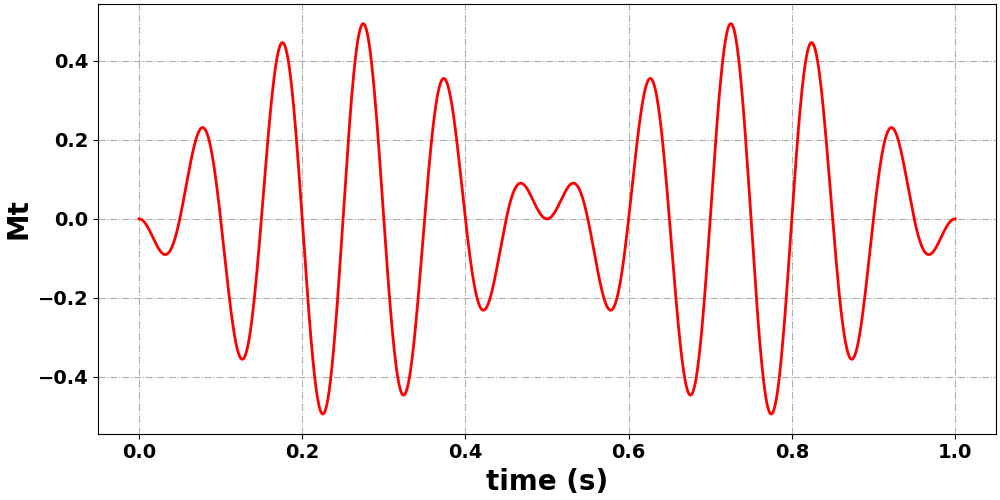

In [22]:
QS.Plotting.Plotting_SpanSelector(t,Mt,"time (s)","Mt","red") 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x71290d4e4440>)

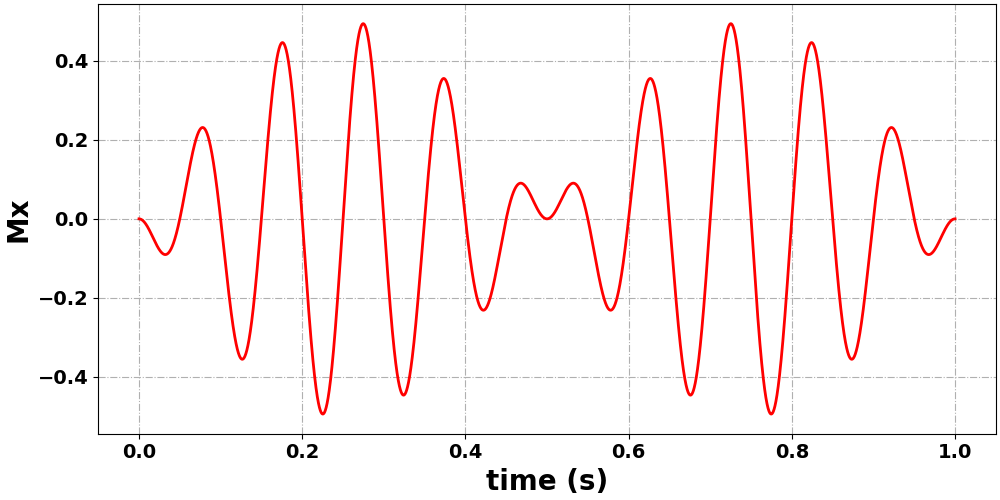

In [23]:
QS.Plotting.Plotting_SpanSelector(t,Mt,"time (s)","Mx","red") 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x71290d326180>)

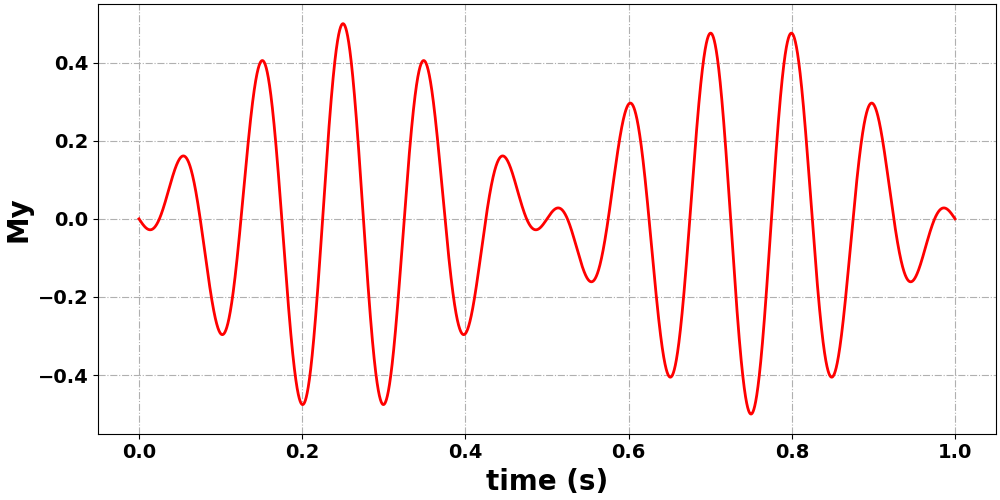

In [24]:
QS.Plotting.Plotting_SpanSelector(t,My,"time (s)","My","red") 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x71290d3b2ed0>)

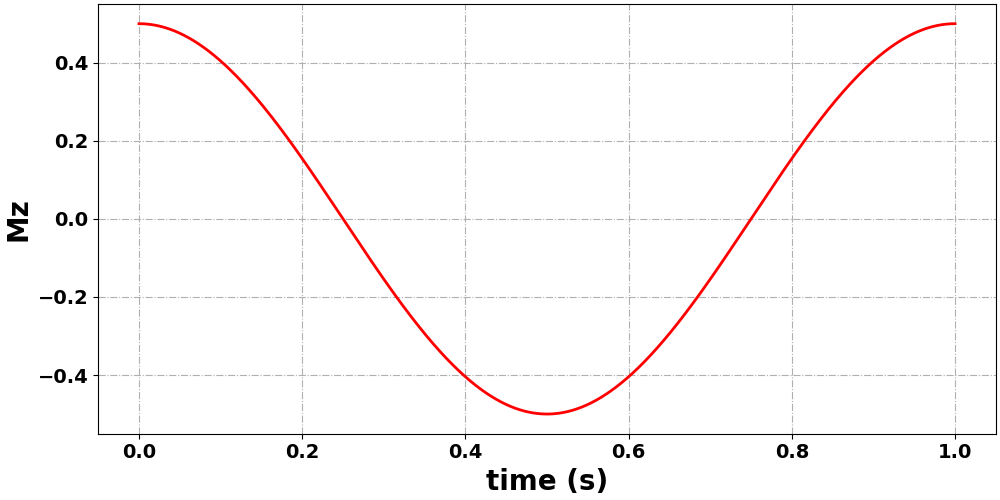

In [25]:
QS.Plotting.Plotting_SpanSelector(t,Mz,"time (s)","Mz","red") 

## Fourier Transform

In [26]:
freq, spectrum = QS.Spro.FourierTransform(Mt,QS.AcqFS,5)

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x71290c151a90>)

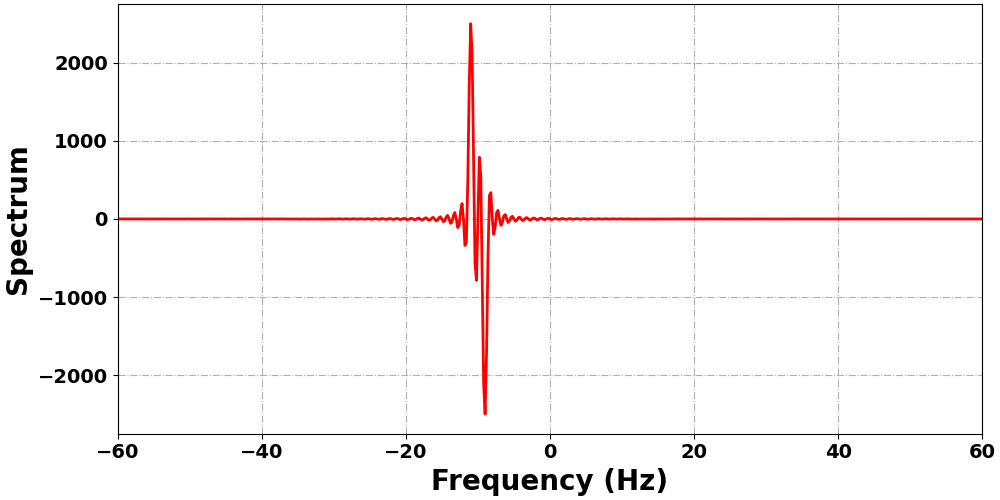

In [27]:
QS.Plotting.PlotXlimt= (-60,60)
#QS.Plotting.PlotYlimt= (0,3500)
QS.Plotting.Plotting_SpanSelector(freq,spectrum,"Frequency (Hz)","Spectrum","red")